# 📝 Prompt Registry & Versioning

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/llmops-genai-platform/prompt-registry/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=llmops-genai-platform/prompt-registry/demo.ipynb)

> **Pain point:** Prompts get pasted into random `.py` files and Slack threads. There's no history, no diff when someone "improves" one, and no way to roll back when a change quietly breaks answers.

**Day 81 of the FDE portfolio** - the first build in *Month 9: LLMOps & GenAI Platform*.

This notebook walks through a tiny, dependency-light **prompt registry** that gives prompts the same discipline we give code and models:

1. **Version** every prompt commit (v1, v2, v3...) with a content hash
2. **Idempotent** commits - identical text never creates a new version
3. **Diff** any two versions as a unified diff
4. **Extract** the `{variables}` a prompt expects
5. **Render** safely - refuse to fill a prompt with missing variables
6. **Promote** exactly one version to *production* (rollback = promote the old one)
7. A **matplotlib** view of how a prompt evolves over its versions

Everything runs standalone on mock data - no API keys, no external services.

## Step 1 - The core registry

We keep it file-backed and boring on purpose: a `bodies/` folder holds the raw prompt text per version, and an `index.json` holds the metadata (version, stage, hash, variables, tags).

The only clever bits are:
- **content hashing** so we can detect "nothing actually changed" and skip the version bump, and
- a **single-production invariant** so there is always exactly one live version per prompt.

The class below is a self-contained copy of `registry.py` so the notebook runs on its own.

In [1]:
from __future__ import annotations

import difflib
import hashlib
import json
import os
import re
import tempfile
from typing import Optional, List, Dict

VALID_STAGES = ("draft", "staging", "production")
_VAR_RE = re.compile(r"\{([a-zA-Z_][a-zA-Z0-9_]*)\}")


def extract_variables(body: str) -> List[str]:
    """Ordered, de-duplicated {placeholder} names in a prompt body."""
    seen: List[str] = []
    for match in _VAR_RE.findall(body):
        if match not in seen:
            seen.append(match)
    return seen


class PromptRegistry:
    def __init__(self, root: str) -> None:
        self.root = root
        self.bodies_dir = os.path.join(root, "bodies")
        self.index_path = os.path.join(root, "index.json")
        os.makedirs(self.bodies_dir, exist_ok=True)
        if not os.path.exists(self.index_path):
            self._write_index([])

    def _read_index(self) -> List[Dict]:
        with open(self.index_path, "r", encoding="utf-8") as fh:
            return json.load(fh)

    def _write_index(self, records: List[Dict]) -> None:
        with open(self.index_path, "w", encoding="utf-8") as fh:
            json.dump(records, fh, indent=2)

    def _body_path(self, name: str, version: int) -> str:
        return os.path.join(self.bodies_dir, name, f"v{version}.txt")

    def commit(self, name: str, body: str, tags: Optional[List[str]] = None,
               author: Optional[str] = None, created_at: Optional[str] = None) -> Dict:
        records = self._read_index()
        existing = [r for r in records if r["name"] == name]
        content_hash = hashlib.sha256(body.encode("utf-8")).hexdigest()[:12]
        if existing:
            latest = max(existing, key=lambda r: r["version"])
            if latest["hash"] == content_hash:
                return latest  # idempotent - no bump
        version = max((r["version"] for r in existing), default=0) + 1
        body_path = self._body_path(name, version)
        os.makedirs(os.path.dirname(body_path), exist_ok=True)
        with open(body_path, "w", encoding="utf-8") as fh:
            fh.write(body)
        record = {
            "name": name, "version": version, "stage": "draft",
            "hash": content_hash, "variables": extract_variables(body),
            "chars": len(body), "tags": list(tags) if tags else [],
            "author": author, "created_at": created_at,
        }
        records.append(record)
        self._write_index(records)
        return record

    def list_prompts(self, name: Optional[str] = None) -> List[Dict]:
        records = self._read_index()
        return [r for r in records if r["name"] == name] if name else records

    def get(self, name: str, version: Optional[int] = None) -> Dict:
        records = [r for r in self._read_index() if r["name"] == name]
        if not records:
            raise KeyError(f"No prompt named {name!r}")
        if version is None:
            return max(records, key=lambda r: r["version"])
        for r in records:
            if r["version"] == version:
                return r
        raise KeyError(f"No version {version} for {name!r}")

    def get_body(self, name: str, version: Optional[int] = None) -> str:
        rec = self.get(name, version)
        with open(self._body_path(name, rec["version"]), "r", encoding="utf-8") as fh:
            return fh.read()

    def production(self, name: str) -> Optional[Dict]:
        for r in self._read_index():
            if r["name"] == name and r["stage"] == "production":
                return r
        return None

    def diff(self, name: str, v1: int, v2: int) -> str:
        left = self.get_body(name, v1).splitlines(keepends=True)
        right = self.get_body(name, v2).splitlines(keepends=True)
        return "".join(difflib.unified_diff(
            left, right, fromfile=f"{name} v{v1}", tofile=f"{name} v{v2}"))

    def render(self, name: str, variables: Dict, version: Optional[int] = None) -> str:
        body = self.get_body(name, version)
        required = extract_variables(body)
        missing = [v for v in required if v not in variables]
        if missing:
            raise KeyError(f"Cannot render {name!r}: missing variables {missing}")
        for key, value in variables.items():
            body = body.replace("{" + key + "}", str(value))
        return body

    def promote(self, name: str, version: int, stage: str) -> Dict:
        if stage not in VALID_STAGES:
            raise ValueError(f"stage must be one of {VALID_STAGES}")
        records = self._read_index()
        target = next((r for r in records
                       if r["name"] == name and r["version"] == version), None)
        if target is None:
            raise KeyError(f"No version {version} for {name!r}")
        if stage == "production":
            for r in records:
                if r["name"] == name and r["stage"] == "production" and r["version"] != version:
                    r["stage"] = "staging"
        target["stage"] = stage
        self._write_index(records)
        return target

print("PromptRegistry ready.")

PromptRegistry ready.


## Step 2 - Commit a few versions of a real prompt

Imagine a support-triage prompt that three people improved over a week. Each commit is a genuine edit, so each becomes a new version.

In [2]:
reg = PromptRegistry(tempfile.mkdtemp(prefix="prompt_registry_"))

v1 = "You are a support agent. Answer the customer question:\n{question}"
v2 = ("You are a helpful support agent for {product}.\n"
      "Answer the customer question clearly and concisely:\n{question}")
v3 = ("You are a helpful support agent for {product}.\n"
      "Rules: be concise, never invent policy, escalate billing issues.\n"
      "Customer question:\n{question}\n\nAnswer:")

for i, body in enumerate([v1, v2, v3], start=1):
    rec = reg.commit("support_triage", body, tags=["support", "triage"],
                     author="phoebe", created_at=f"2026-07-18T09:0{i}:00")
    print(f"committed v{rec['version']:>2}  hash={rec['hash']}  vars={rec['variables']}")

committed v 1  hash=3fa7a441864f  vars=['question']
committed v 2  hash=c659ea5519c3  vars=['product', 'question']
committed v 3  hash=d7000da8ff0d  vars=['product', 'question']


### Idempotent commits

Re-committing the *exact same* text should **not** create a phantom v4. The registry hashes the body and returns the existing record instead.

In [3]:
same = reg.commit("support_triage", v3)
print(f"Re-commit identical body -> still v{same['version']} (no new version created)")

Re-commit identical body -> still v3 (no new version created)


## Step 3 - See the full version history

Every version, its stage, content hash, character count and detected variables in one table.

In [4]:
import pandas as pd

def to_frame(reg, name=None):
    rows = []
    for r in reg.list_prompts(name):
        rows.append({
            "name": r["name"], "version": r["version"], "stage": r["stage"],
            "hash": r["hash"], "chars": r["chars"],
            "variables": ", ".join(r["variables"]), "tags": ", ".join(r["tags"]),
        })
    return pd.DataFrame(rows)

to_frame(reg)

,name,version,stage,hash,chars,variables,tags
0,support_triage,1,draft,3fa7a441864f,65,question,"support, triage"
1,support_triage,2,draft,c659ea5519c3,109,"product, question","support, triage"
2,support_triage,3,draft,d7000da8ff0d,150,"product, question","support, triage"


## Step 4 - Diff two versions

The whole point of versioning is being able to answer *"what actually changed?"*. A unified diff makes prompt edits reviewable, just like code.

In [5]:
print(reg.diff("support_triage", 1, 3))

--- support_triage v1
+++ support_triage v3
@@ -1,2 +1,6 @@
-You are a support agent. Answer the customer question:
-{question}+You are a helpful support agent for {product}.
+Rules: be concise, never invent policy, escalate billing issues.
+Customer question:
+{question}
+
+Answer:


## Step 5 - Promote to production, then roll back safely

Only one version is ever *live*. Promoting a new version automatically demotes the old one to `staging` - so rollback is just promoting the previous version again.

In [6]:
# Ship v3.
reg.promote("support_triage", 3, "production")
print("Production is now v", reg.production("support_triage")["version"])

# Hotfix: expand the escalation rule -> v4, ship it.
v4 = v3.replace("escalate billing issues", "escalate billing and refund issues")
rec4 = reg.commit("support_triage", v4, created_at="2026-07-18T11:00:00")
reg.promote("support_triage", rec4["version"], "production")

live = [r for r in reg.list_prompts("support_triage") if r["stage"] == "production"]
print(f"Live versions: {len(live)} (invariant: exactly 1) -> v{live[0]['version']}")

# Rollback in one line if v4 misbehaves:
# reg.promote("support_triage", 3, "production")

Production is now v 3
Live versions: 1 (invariant: exactly 1) -> v4


## Step 6 - Render the production prompt (with a safety guard)

Filling `{placeholders}` is where silent bugs live - a `{typo}` that never gets replaced ships straight to the model. The registry refuses to render when a required variable is missing.

In [7]:
out = reg.render("support_triage",
                 {"product": "Acme Cloud",
                  "question": "How do I reset my password?"})
print(out)
print("\n--- missing-variable guard ---")
try:
    reg.render("support_triage", {"product": "Acme Cloud"})  # no question
except KeyError as exc:
    print("Blocked:", exc)

You are a helpful support agent for Acme Cloud.
Rules: be concise, never invent policy, escalate billing and refund issues.
Customer question:
How do I reset my password?

Answer:

--- missing-variable guard ---
Blocked: "Cannot render 'support_triage': missing variables ['question']"


## Step 7 - Visualize prompt evolution

A quick chart of how the prompt grew (character count) across versions, with the production version highlighted. Longer isn't automatically better - but *seeing* the growth catches prompts that have quietly ballooned into 2,000-character monsters.

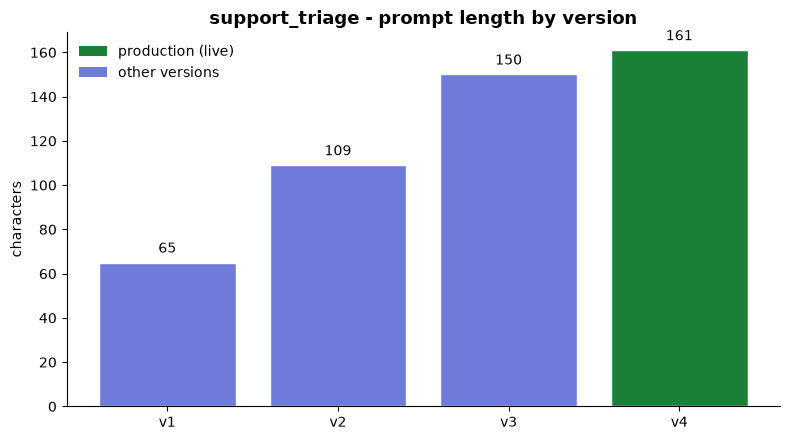

In [8]:
import matplotlib.pyplot as plt

records = sorted(reg.list_prompts("support_triage"), key=lambda r: r["version"])
versions = [r["version"] for r in records]
chars = [r["chars"] for r in records]
prod_v = reg.production("support_triage")["version"]
colors = ["#1a7f37" if r["version"] == prod_v else "#6e7bd8" for r in records]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar([f"v{v}" for v in versions], chars, color=colors, edgecolor="white")
ax.set_title("support_triage - prompt length by version", fontsize=13, fontweight="bold")
ax.set_ylabel("characters")
ax.spines[["top", "right"]].set_visible(False)
for bar, c in zip(bars, chars):
    ax.text(bar.get_x() + bar.get_width() / 2, c + 3, str(c),
            ha="center", va="bottom", fontsize=10)
# Legend proxy for the production highlight.
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="#1a7f37", label="production (live)"),
    Patch(facecolor="#6e7bd8", label="other versions"),
], frameon=False)
plt.tight_layout()
plt.savefig("prompt_evolution.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

| Capability | What it prevents |
|---|---|
| Versioned commits + content hash | Lost history; phantom duplicate versions |
| Unified diff | "Who changed this prompt and why?" mysteries |
| Variable extraction + render guard | Un-filled `{typo}` placeholders shipping to the model |
| Single-production promotion | Two "live" prompts; scary rollbacks |

A prompt registry is the smallest first step of an LLMOps platform: once prompts are *versioned artifacts* instead of scattered strings, everything downstream (eval, cost tracking, A/B tests) has something stable to hang off.

## Try your own

Uncomment and run - register your own prompt, commit a v2, and diff them.

In [9]:
# my = PromptRegistry(tempfile.mkdtemp(prefix="my_prompts_"))
# my.commit("classifier", "Classify the sentiment of: {text}")
# my.commit("classifier", "Classify sentiment as positive/negative/neutral: {text}")
# print(my.diff("classifier", 1, 2))
# print(my.render("classifier", {"text": "I love this product!"}, version=2))

---

**Day 81 / 120** - part of Phoebe's [Field Engineer portfolio](https://github.com/phoebefu6/phoebe-the-builder) (*Month 9: LLMOps & GenAI Platform*).

Run the interactive version locally:

```bash
pip install -r requirements.txt
streamlit run app.py
```